# Sesión 1

## Motivación

Ya exploramos brevemente algunos conceptos clave que abordaremos a lo largo del curso. Ahora, para introducir y motivar el enfoque de manera más concreta, realizaremos un ejercicio práctico.

### Ejercicio de motivación

In [4]:
from sklearn.datasets import load_iris
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt                                                

Disponible en: [Sklearn](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_iris.html#sklearn.datasets.load_iris)

#### Machine Learning, everywhere

![](../images/memes/eee1.jpeg)

Sabemos que una de las ramas más relevantes de la inteligencia artificial es el _Machine Learning_. Esta disciplina, a través de diversos modelos y algoritmos, tiene como objetivo principal generar predicciones a partir de _datos_. 

En este contexto, analizaremos el clásico conjunto de datos `iris`. A partir de sus características —como la _longitud_ y la _altura_ de los sépalos— construiremos un modelo de clasificación que nos permita _predecir_ a qué especie pertenece cada flor.

In [5]:
# Carga los datos desde load_iris()
datos = load_iris()

![](../images/sesion1_iris.png)

**Figura 1.** Flores de Iris. Disponibles en: [Kaggle](https://www.kaggle.com/code/sunaysawant/iris-eda) 

| **Propiedad**         | **Valor**       | **Explicación** |
|------------------------|-----------------|-----------------|
| **Clases**             | 3               | Las especies de iris: *setosa*, *versicolor* y *virginica*. |
| **Muestras por clase** | 50              | Cada especie tiene 50 flores |
| **Muestras totales**   | 150             | 3 clases × 50 muestras |
| **Dimensionalidad**    | 4               | Cada flor tiene 4 características numéricas. |
| **Características**    | Reales, positivas | Todas las variables (longitud y ancho de sépalo y pétalo) son valores reales y positivos (no hay negativos). |

In [6]:
#datos

In [7]:
# Asigna las variables en X
X = datos['data'][:, 0:2].astype(int)

In [8]:
# Asigna las variables en y
y = datos['target']
y

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2])

In [9]:
print(len(X))
print(len(y))

150
150


In [10]:
# Genera un dataframe que integre X e y
df = pd.DataFrame(data=X,
                  columns=datos['feature_names'][:2])
df['y'] = y
df

,sepal length (cm),sepal width (cm),y
0,5,3,0
1,4,3,0
2,4,3,0
3,4,3,0
4,5,3,0
...,...,...,...
145,6,3,2
146,6,2,2
147,6,3,2
148,6,3,2


In [11]:
help(df.rename)

Help on method rename in module pandas.core.frame:

rename(
    mapper: 'Renamer | None' = None,
    *,
    index: 'Renamer | None' = None,
    columns: 'Renamer | None' = None,
    axis: 'Axis | None' = None,
    copy: 'bool | None' = None,
    inplace: 'bool' = False,
    level: 'Level | None' = None,
    errors: 'IgnoreRaise' = 'ignore'
) -> 'DataFrame | None' method of pandas.core.frame.DataFrame instance
    Rename columns or index labels.

    Function / dict values must be unique (1-to-1). Labels not contained in
    a dict / Series will be left as-is. Extra labels listed don't throw an
    error.

    See the :ref:`user guide <basics.rename>` for more.

    Parameters
    ----------
    mapper : dict-like or function
        Dict-like or function transformations to apply to
        that axis' values. Use either ``mapper`` and ``axis`` to
        specify the axis to target with ``mapper``, or ``index`` and
        ``columns``.
    index : dict-like or function
        Alternativ

In [12]:
# Renombra las columnas [length y width]
df.rename({'sepal length (cm)': 's_length',
           'sepal width (cm)': 's_width'},
           axis=1,
           inplace=True)

In [13]:
df.columns

Index(['s_length', 's_width', 'y'], dtype='object')

In [14]:
# Genera un conteo por tipo de flor
df['y'].value_counts()

y
0    50
1    50
2    50
Name: count, dtype: int64

| Tipo de flor | Número |
| ------------ | ------ |
| Setosa       | 0      |
| Versicolor   | 1      |
| Virginica    | 2      |

<details>
  <summary> 📊 </summary>
  
np.random.seed(1)

fig, ax = plt.subplots(figsize=(8, 6)) 

sc = ax.scatter(
    df.length + np.random.normal(loc=0, scale=0.1, size=len(df)),
    df.width + np.random.normal(loc=0, scale=0.1, size=len(df)),
    c=df.target,
    cmap='cividis',
    alpha=0.6,
    edgecolors='w',
    linewidths=0.5,
    s=60
)


ax.set_xlabel("Sepal length (cm)", fontsize=12)
ax.set_ylabel("Sepal width (cm)", fontsize=12)
ax.set_title("Clasificación por longitud y ancho del sépalo", fontsize=14, pad=15)

ax.grid(True, linestyle='--', alpha=0.3)

cbar = fig.colorbar(sc, ax=ax)
cbar.set_label('Clase', fontsize=11)

plt.tight_layout()
plt.show()
</details>

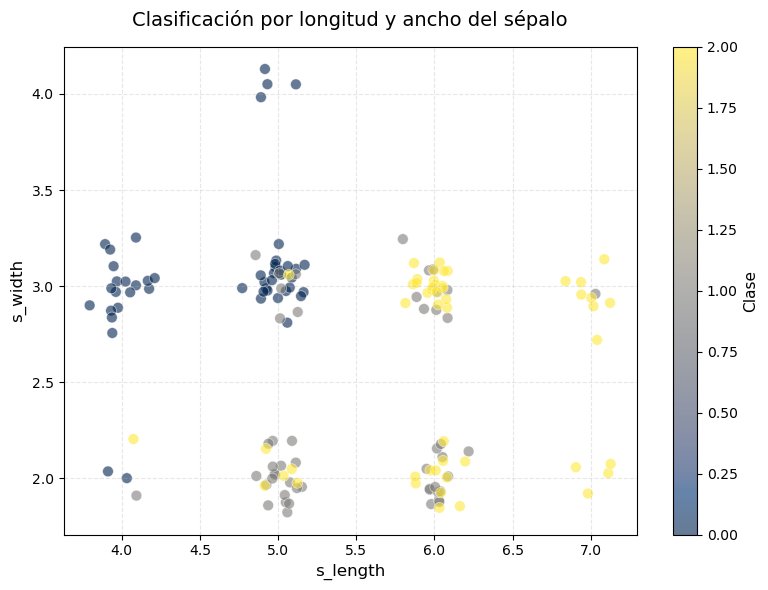

In [18]:
# Gráfica
import numpy as np
np.random.seed(1)

fig, ax = plt.subplots(figsize=(8, 6)) 

sc = ax.scatter(
    df.s_length + np.random.normal(loc=0, scale=0.1, size=len(df)),
    df.s_width + np.random.normal(loc=0, scale=0.1, size=len(df)),
    c=df.y,
    cmap='cividis',
    alpha=0.6,
    edgecolors='w',
    linewidths=0.5,
    s=60
)


ax.set_xlabel("s_length", fontsize=12)
ax.set_ylabel("s_width", fontsize=12)
ax.set_title("Clasificación por longitud y ancho del sépalo", fontsize=14, pad=15)

ax.grid(True, linestyle='--', alpha=0.3)

cbar = fig.colorbar(sc, ax=ax)
cbar.set_label('Clase', fontsize=11)

plt.tight_layout()
plt.show()

#### ¿qué observamos?

<details>
  <summary> 🧿 </summary>
  
  * Clase 0 (color azul oscuro) está bien separada: se agrupa con sépalos más cortos y más anchos.

  * Clase 1 y Clase 2 (gris y amarillo) están más superpuestas, especialmente en la región de sépalos largos y estrechos.

  * Esto sugiere que, al menos con las variables ``sepal length`` y ``sepal width``, la clase 0 se puede clasificar con mayor precisión que las otras dos.
</details>

**Pregunta:**

_¿Cuáles modelos de clasificación podríamos usar para resolver este problema?_

In [19]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier

In [20]:
help(train_test_split)

Help on function train_test_split in module sklearn.model_selection._split:

train_test_split(
    *arrays,
    test_size=None,
    train_size=None,
    random_state=None,
    shuffle=True,
    stratify=None
)
    Split arrays or matrices into random train and test subsets.

    Quick utility that wraps input validation,
    ``next(ShuffleSplit().split(X, y))``, and application to input data
    into a single call for splitting (and optionally subsampling) data into a
    one-liner.

    Read more in the :ref:`User Guide <cross_validation>`.

    Parameters
    ----------
    *arrays : sequence of indexables with same length / shape[0]
        Allowed inputs are lists, numpy arrays, scipy-sparse
        matrices or pandas dataframes.

    test_size : float or int, default=None
        If float, should be between 0.0 and 1.0 and represent the proportion
        of the dataset to include in the test split. If int, represents the
        absolute number of test samples. If None, the value

In [21]:
# Genera un clasificador de árbol de decisión
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=42)

In [22]:
# Predicciones
ml_clf = DecisionTreeClassifier(max_depth=1)
ml_clf.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=1)

In [23]:
# y_pred
y_pred = ml_clf.predict(X_test)

In [25]:
# y_pred
y_pred

array([2, 0, 2, 2, 2, 0, 0, 2, 2, 0, 2, 0, 0, 0, 0])

In [26]:
# y_test
y_test

array([1, 0, 2, 1, 1, 0, 1, 2, 1, 1, 2, 0, 0, 0, 0])

In [27]:
# y_pred == y_test (máscara booleana)
mask = y_pred == y_test

In [28]:
# promedio de aciertos con y_test
mask.mean()

np.float64(0.6)

#### ¿Por qué usar una distribución conjunta para clasificar?

Anteriormente vimos que un modelo de clasificación (como árboles de decisión) presenta un _score_ del 60%.

Podemos adoptar un **enfoque probabilístico** para modelar la situación a partir de los datos disponibles.

In [29]:
# Convierte en df los datos de train
train_df = pd.DataFrame(data=X_train,
                        columns=['L', 'W'])
train_df['T'] = y_train
train_df

,L,W,T
0,6,3,1
1,6,3,2
2,5,2,1
3,5,2,1
4,6,2,2
...,...,...,...
130,6,2,1
131,4,2,2
132,5,4,0
133,5,2,1


In [30]:
# Convierte en df los datos de test
test_df = pd.DataFrame(data=X_test,
                       columns=['L', 'W'])
test_df['T'] = y_test
test_df

,L,W,T
0,6,2,1
1,5,3,0
2,7,2,2
3,6,2,1
4,6,2,1
5,5,3,0
6,5,2,1
7,6,3,2
8,6,2,1
9,5,2,1


In [31]:
# Imprime los valores únicos de L, W y T
print(train_df['L'].nunique())
print(train_df['W'].nunique())
print(train_df['T'].nunique())

4
3
3


Primero, veámos en la tabla siguiente que las columnas (`L`, `W` `T`) representan todas las posibles combinaciones de valores de cada variable.

La tabla muestra la **distribución conjunta** de tres variables (`L`, `W`, `T`).

Al estimar la distribución conjunta de las variables $(L)$ (longitud del tallo), $(W)$ (ancho del tallo) y $(T)$ (tipo de flor), obtenemos un modelo probabilístico completo:

$$P(L, W, T)$$

Este enfoque tiene varias ventajas:

- Captura todas las relaciones entre las variables.
- Nos permite derivar distribuciones condicionales útiles para clasificación.

In [32]:
# Generamos un conteo relativo (para construir la distribución empírica)
train_df.groupby(['L', 'W', 'T']).size()

L  W  T
4  2  0     2
      1     1
      2     1
   3  0    16
5  2  1    17
      2     5
   3  0    22
      1     6
      2     1
   4  0     4
6  2  1    10
      2    11
   3  1     9
      2    18
7  2  2     3
   3  1     1
      2     8
dtype: int64

Tenemos $4 * 3 * 3 = 36$ posibles combinaciones:

**NOTA:** no todas las combinaciones posibles de (`L`, `W` `T`) aparecen en los datos. `groupby().size()` solo muestra las combinaciones que realmente están presentes en el DataFrame.

Las combinaciones que no ocurren ni una sola vez, no aparecen en la salida porque su conteo es $0$.

| L | W | T | Frecuencia |
|---|---|---|------------|
| 4 | 2 | 0 | 2          |
| 4 | 2 | 1 | 1          |
| 4 | 2 | 2 | 1          |
| 4 | 3 | 0 | 16         |
| 5 | 2 | 1 | 17         |
| 5 | 2 | 2 | 5          |
| 5 | 3 | 0 | 22         |
| 5 | 3 | 1 | 6          |
| 5 | 3 | 2 | 1          |
| 6 | 2 | 1 | 10         |
| 6 | 2 | 2 | 11         |
| 6 | 3 | 1 | 9          |
| 6 | 3 | 2 | 18         |
| 7 | 2 | 2 | 3          |
| 7 | 3 | 1 | 1          |
| 7 | 3 | 2 | 8          |

In [33]:
# Generamos la distribución empírica conjunta (conteo/normalización)
empirical_joint_distr = train_df.groupby(['L', 'W', 'T']).size() / len(train_df)
empirical_joint_distr

L  W  T
4  2  0    0.014815
      1    0.007407
      2    0.007407
   3  0    0.118519
5  2  1    0.125926
      2    0.037037
   3  0    0.162963
      1    0.044444
      2    0.007407
   4  0    0.029630
6  2  1    0.074074
      2    0.081481
   3  1    0.066667
      2    0.133333
7  2  2    0.022222
   3  1    0.007407
      2    0.059259
dtype: float64

In [34]:
# ¿la distribución empírica conjunta suma 1?
empirical_joint_distr.sum()

np.float64(1.0)

In [ ]:
# 

Por ejemplo, a partir de la distribución conjunta podemos obtener la probabilidad de que una flor pertenezca a cierta clase $(T)$, dado que observamos un par de medidas $((L, W))$:

![](../images/sesion1-prob-cond.png)

Con esta información, podemos construir un clasificador probabilístico de la siguiente manera:

1. La distribución condicional nos proporciona una probabilidad para cada posible valor $(t)$ que puede tomar la variable $(T)$ (por ejemplo, $(t = 0, 1, 2 )$). Como nuestro objetivo es predecir la clase más probable, elegimos el valor de $(t)$ que maximiza esta probabilidad:

$$
\hat{t} = \arg\max_{t} P(T = t \mid L = \ell, W = w)
$$

2. Este procedimiento se conoce como el **clasificador MAP (Maximum A Posteriori)**. Es importante destacar que no necesitamos calcular explícitamente la distribución condicional, ya que:

$$
P(T = t \mid L = \ell, W = w) = \frac{P(T = t, L = \ell, W = w)}{P(L = \ell, W = w)}
$$

3. Dado que el denominador $(P(L = \ell, W = w))$ no depende de $(t)$, podemos omitirlo durante la maximización. Esto nos permite simplificar el clasificador a:

$$
\hat{t} = \arg\max_{t} P(T = t, L = \ell, W = w)
$$

Este enfoque nos permite realizar clasificación directamente a partir de la distribución conjunta estimada, sin necesidad de modelos adicionales.

In [35]:
# empirical_joint_distr[7, 3].idxmax()
empirical_joint_distr.loc[(5, 3)].idxmax()

np.int64(0)

$$
\hat{t} = \arg\max_{t} \, \hat{P}(T = t, L = 5, W = 3)
$$

In [37]:
# Generar por a partir de la distribución emírica el argmax
pred = []

for _, row in test_df.iterrows():
    pred.append(empirical_joint_distr[(row['L'], row['W'])].idxmax())

y_pred_prob = np.array(pred)
y_pred_prob

array([2, 0, 2, 2, 2, 0, 1, 2, 2, 1, 2, 0, 0, 0, 0])

In [38]:
# y_test
y_test

array([1, 0, 2, 1, 1, 0, 1, 2, 1, 1, 2, 0, 0, 0, 0])

In [39]:
# promedio de aciertos con y_test
mask = y_pred_prob == y_test

In [40]:
mask.mean()

np.float64(0.7333333333333333)

### 📌 Conclusión

**Pasos que seguiste (en términos probabilísticos)**

1. **Estimación de la distribución conjunta**

   Calculaste la probabilidad conjunta $(P(L = \ell, W = w, T = t))$ a partir de los datos, contando la frecuencia de cada combinación y normalizando sobre el total.  

2. **Normalización**

   Dividiste los conteos conjuntos por el total de observaciones, obteniendo así una estimación empírica de las probabilidades.  
   → Esto convierte los conteos en una **distribución de probabilidad válida**.

3. **Cálculo de la probabilidad condicional**

   usaste la regla de Bayes para pasar de probabilidades conjuntas a probabilidades condicionales:

   $$
   P(T = t \mid L = \ell, W = w) = \frac{P(L = \ell, W = w, T = t)}{P(L = \ell, W = w)}
   $$

4. **Predicción con argumento máximo (MAP)**

   Elegiste la clase con mayor probabilidad condicional:

   $$
   \hat{t} = \arg\max_t P(T = t \mid L = \ell, W = w)
   $$

   → Esto significa que, dadas las evidencias (los valores de $L$ y $W$), escoges la clase más plausible según los datos observados.

5. **Clasificación final**

   Aplicaste este procedimiento a cada punto del conjunto de datos, generando predicciones basadas únicamente en la distribución conjunta estimada.

**OJO**

Que ambos modelos obtengan el mismo _score_ no significa que sean equivalentes, sino que **dado el conjunto de datos y la tarea, ambos llegaron al límite razonable de desempeño**.

Ambos tienen ventajas:
- El modelo probabilístico aporta una visión basada en evidencia y probabilidades.
- El árbol de decisión proporciona reglas claras y visualmente interpretables.

[_Créditos del ejercicio_](https://github.com/esjimenezro/mgp2025/tree/main/m1-intro-modelado-probabilistico/c1-motivacion)